Importing all libraries necessary for the project:

- pandas / numpy: data manipulation and numerical algebra
- matplotlib / seaborn: graphical visualizations
- sklearn: preprocessing, clustering, and evaluation metrics
- scipy: hierarchical dendrogram
- hashlib: data file integrity verification (SHA-256)
- pathlib.Path: portable directory creation

In [ ]:
#packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib, time, warnings, json
from pathlib import Path

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, pairwise_distances_argmin)
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

warnings.filterwarnings('ignore')
GLOBAL_SEED=42 # global seed
np.random.seed(GLOBAL_SEED)
sns.set_theme(style='whitegrid', palette='tab10') # plotting style
# whitegrid = white background with gridlines; tab10 = default color palette

for folder in ['figures', 'tables']: # create folders for figures and tables
    Path(folder).mkdir(exist_ok=True) # don't raise an error if they already exist


## 1. Dataset Documentation

Loading the CSV file of hotel reservations (119,390 rows x 32 columns).
The SHA-256 is calculated before reading the file to verify data integrity — it ensures that we are always using exactly the same version of the dataset, essential for reproducibility.


In [ ]:
data = './content/hotel_bookings_course_release_v1.csv'

#calculate SHA-256 hash of the file (integrity check)
with open(data, 'rb') as f:
    sha256 = hashlib.sha256(f.read()).hexdigest()

df = pd.read_csv(data) #create a df
print(f'Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
#output:119,390 linhas x 32 colunas


Shape: 119,390 linhas x 32 colunas


## 2. Exploratory Data Analysis

Basic descriptive statistics (head + describe) to get an initial understanding of the data: variable types, ranges, possible outliers.

In [ ]:
#basic statistics
display(df.head(3)) #first 3 rows
display(df.describe().round(2)) #descriptive statistics

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


In [ ]:
#Missingness report by attribute type

#identify numerical and categorical columns
numeric_raw=df.select_dtypes(include=['int64','float64']).columns.tolist() #int and float
categ_raw=df.select_dtypes(include=['object']).columns.tolist() #object

#count missing values for each column
miss=df.isnull().sum()
miss_pct=(miss/len(df)*100).round(2) #percentage of missing values
#summary table with number of missing values, the percentage and data type
miss_df=pd.DataFrame({'missing_n':miss,'missing_%':miss_pct, 'dtype':df.dtypes,'type':['num' if c in numeric_raw else 'cat'
                                                       for c in df.columns]})
#keep only columns with missing values and sort them
miss_df = miss_df[miss_df.missing_n>0].sort_values('missing_%', ascending=False)


display(miss_df)
print()

,missing_n,missing_%,dtype,type
company,112593,94.31,float64,num
agent,16340,13.69,float64,num
country,488,0.41,object,cat
children,4,0.00,float64,num


Missing values ​​per variable:
- 'company': 94% missing — high cardinality identifier, will be replaced by binary variable 'has_company'
- 'agent': 14% missing — same, will be replaced by 'has_agent'
- 'country': 0.4% missing — filled with 'Unknown'
- 'children': <0.01% missing — filled with 0

Analysis of outliers in key numerical variables using the IQR rule:
upper_fence = Q3 + 1.5 * IQR
Variables with strong positive skewness (right-skew) are identified and visualized in histograms with a clip at the 99th percentile (to avoid distorting the axis).
These variables will be transformed with log1p before clustering.

,mean,50%,max,IQR,upper_fence,outlier_%
lead_time,104.01,69.00,737.0,142.00,373.00,2.52
stays_in_week_nights,2.50,2.00,50.0,2.00,6.00,2.81
stays_in_weekend_nights,0.93,1.00,19.0,2.00,5.00,0.22
adults,1.86,2.00,55.0,0.00,2.00,5.26
children,0.10,0.00,10.0,0.00,0.00,7.19
babies,0.01,0.00,10.0,0.00,0.00,0.77
previous_cancellations,0.09,0.00,26.0,0.00,0.00,5.43
previous_bookings_not_canceled,0.14,0.00,72.0,0.00,0.00,3.03
total_of_special_requests,0.57,0.00,5.0,1.00,2.50,2.41
required_car_parking_spaces,0.06,0.00,8.0,0.00,0.00,6.21


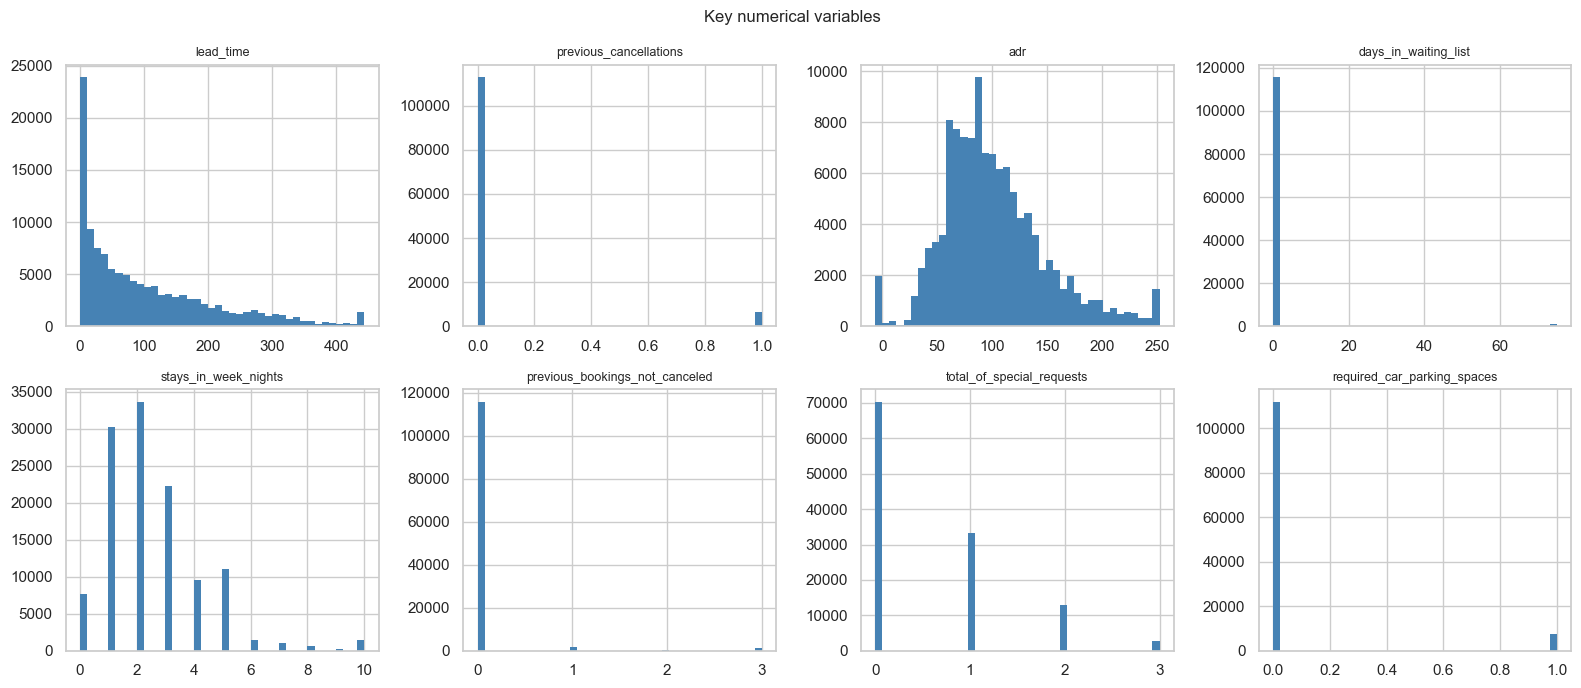

In [ ]:
#Outlier report & distribution plots

#select the main numerical variables for outlier analysis
#these variables are important for booking behavior, customer profile,
#and hotel reservation patterns
key_num = ['lead_time','stays_in_week_nights','stays_in_weekend_nights',
           'adults','children','babies','previous_cancellations',
           'previous_bookings_not_canceled','total_of_special_requests',
           'required_car_parking_spaces','adr']
#descriptive statistics
stats = df[key_num].describe(percentiles=[.25,.75,.95,.99]).T
stats['IQR']=stats['75%']-stats['25%'] #interquartile range
stats['upper_fence'] = stats['75%'] + 1.5 * stats['IQR'] #upper fence
stats['outlier_%']= [round((df[c] > stats.loc[c,'upper_fence']).mean()*100, 2) for c in key_num] #percentage of observations above the upper fence
display(stats[['mean','50%','max','IQR','upper_fence','outlier_%']].round(2)) #display

#create subplot grid for histogram visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
#select variables with strong right-skewness because these usually require special treatment in modeling
skewed = ['lead_time','previous_cancellations','adr',
          'days_in_waiting_list','stays_in_week_nights',
          'previous_bookings_not_canceled','total_of_special_requests',
          'required_car_parking_spaces']
for ax, col in zip(axes.flat, skewed):
    clipped = df[col].clip(upper=df[col].quantile(0.99))
    ax.hist(clipped, bins=40, color='steelblue', edgecolor='none')
    ax.set_title(col, fontsize=9); ax.set_xlabel('')
plt.suptitle('Key numerical variables', fontsize=12)
plt.tight_layout()
plt.savefig('figures/eda_distributions.png', dpi=120, bbox_inches='tight') #save distribution plots
plt.show()

## 3. Feature Selection Table

Segmentation / index time = immediately after the initial booking is created.


## 4. Preprocessing Pipeline

In [ ]:
df2=df.copy() #copy of df

#Remove rows with zero guests (data quality issue)
no_guests = (df2['adults'] + df2['children'].fillna(0) + df2['babies']) == 0
print(f'Linhas com 0 hospedes removidas: {no_guests.sum()}')  # 180 linhas
df2 = df2[~no_guests].reset_index(drop=True)

#Impute missing values
df2['children'] = df2['children'].fillna(0) #in children column
df2['country']  = df2['country'].fillna('Unknown') #in countries

#create new features
df2['total_nights']=df2['stays_in_weekend_nights'] + df2['stays_in_week_nights'] #number of nights
df2['party_size']=df2['adults'] + df2['children'] + df2['babies'] #group size
df2['has_children']=((df2['children'] + df2['babies']) > 0).astype(int) #whether children present
df2['has_agent']=(df2['agent'].notna() & (df2['agent'] != 0)).astype(int) #whether booked via agent
df2['has_company']=(df2['company'].notna() & (df2['company'] != 0)).astype(int) #whether corporate booking
df2['has_parking']= (df2['required_car_parking_spaces'] >= 1).astype(int) #parking requested

#group countries: top-15 + Other to avoid too many categories
TOP_N=15
top_countries=df2['country'].value_counts().head(TOP_N).index.tolist() #select the top 15
df2['country_grouped']=df2['country'].apply(lambda x: x if x in top_countries else 'Other') #others become 'Other'

#Replace 'Undefined' meal with 'SC'
df2['meal_clean']=df2['meal'].replace({'Undefined': 'SC'})

#Cap special requests (max 4)
df2['special_req_capped'] = df2['total_of_special_requests'].clip(upper=4)

#log1p transformations for positively skewed variables (to mitigate outlier effects)
df2['lead_time_log']= np.log1p(df2['lead_time'])
df2['prev_cancel_log']= np.log1p(df2['previous_cancellations'])
df2['prev_not_cancel_log']= np.log1p(df2['previous_bookings_not_canceled'])

print(f'Dataset limpo: {df2.shape[0]:,} linhas x {df2.shape[1]} colunas') #size of cleaned dataset after these changes


Linhas com 0 hospedes removidas: 180
Dataset limpo: 119,210 linhas x 44 colunas


Definition of input feature sets:
- NUMERICAL_FEATURES: transformed with log1p and StandardScaler
- BINARY_FEATURES: passed directly (0/1)
- CATEGORICAL_FEATURES: one-hot encoding

In [ ]:

#Feature sets

NUMERICAL_FEATURES = ['lead_time_log', #booking anticipation
    'total_nights', #stay length
    'party_size',  #group composition
    'prev_cancel_log', #cancellation history
    'prev_not_cancel_log', #loyalty signal
    'special_req_capped',]#service preferences
BINARY_FEATURES = ['has_children',#if has children
    'has_agent',  #booked via agent
    'has_company', #corporate booking
    'has_parking', ] #car-parking requested
CATEGORICAL_FEATURES = ['hotel', #property type
    'meal_clean',  #what type of meal is consuming
    'market_segment', #if comes with a company etc
    'distribution_channel', #Online TA etc
    'deposit_type',#refundable or not
    'customer_type',
    'reserved_room_type',#can say a lot about the type of customer
    'arrival_date_month',#seasonality / month
    'country_grouped',]
ALL_INPUT = NUMERICAL_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES #combine all inputs
print(f'Input features: {len(NUMERICAL_FEATURES)} numerical + {len(BINARY_FEATURES)} binary + {len(CATEGORICAL_FEATURES)} categorical')
print(f'Total raw input columns: {len(ALL_INPUT)}')
print()

Input features: 6 numerical + 4 binary + 9 categorical
Total raw input columns: 19



Construction of the ColumnTransformer with two scaling variants:
- R0 (Standard): StandardScaler — extreme outliers may change
- R1 (Robust): RobustScaler — more resistant to outliers (uses median and IQR)
- Numeric pipeline: inputs median -> scale
- Categorical pipeline: inputs mode -> one-hot encoding
- Final result: 73 dimensions in both representations

In [ ]:

#Build ColumnTransformer (R0:Standard, R1:Robust)

def build_preprocessor(scaler_type='standard'):
    sc=StandardScaler() if scaler_type == 'standard' else RobustScaler() #Create the two types of scaler
    num_pipe = Pipeline([ #numeric pipeline
        ('imputer', SimpleImputer(strategy='median')), #impute missing values with median
        ('scaler',  sc)
    ])
    cat_pipe = Pipeline([ #categorical pipeline
        ('imputer', SimpleImputer(strategy='most_frequent')),# impute missing values with most frequent
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', num_pipe, NUMERICAL_FEATURES), #apply num pipeline to numerical features
        ('bin', 'passthrough',BINARY_FEATURES),
        ('cat', cat_pipe,CATEGORICAL_FEATURES), #apply cat pipeline to categorical features
    ])
#build different matrices
X_raw=df2[ALL_INPUT]
#with R0
prep_R0= build_preprocessor('standard')
X_R0= prep_R0.fit_transform(X_raw)
#with R1
prep_R1=build_preprocessor('robust')
X_R1=prep_R1.fit_transform(X_raw)

# Get feature names for distance contribution analysis
ohe_names = prep_R0.named_transformers_['cat']['ohe'] \
               .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
#names of features
FEATURE_NAMES = NUMERICAL_FEATURES + BINARY_FEATURES + ohe_names


print(f'final R0:{X_R0.shape}')
print(f'final R1:{X_R1.shape}')

final R0:(119210, 73)
final R1:(119210, 73)


Calculate the average Euclidean distance per block (numeric, binary, categorical) in 500 random pairs from a sample of 2000 observations.
Result: Numeric 59.6%, Binary 2.7%, Categorical 37.7%
No block exceeds 60% — balanced representation, no need to rebalance weights.

In [ ]:
np.random.seed(GLOBAL_SEED)
s_idx= np.random.choice(len(X_R0), size=2000, replace=False) #select 2000 random indices
X_samp= X_R0[s_idx] #choose these from X_R0

#create 500 random pairs of points from X_samp
n_pairs=500
i1=np.random.choice(len(X_samp), n_pairs) #index 1
i2=np.random.choice(len(X_samp), n_pairs) #index 2
dsq=(X_samp[i1] - X_samp[i2])**2 #compute squared Euclidean distance between them

n_num=len(NUMERICAL_FEATURES) #number of numerical variables
n_bin=len(BINARY_FEATURES) #number of binary variables

contrib = {'Numerical': dsq[:, :n_num].sum(axis=1).mean(), #sum squared distances within numerical block and average
           #to see how much numericals contribute to total
    'Binary': dsq[:, n_num:n_num+n_bin].sum(axis=1).mean(),
    'Categorical (one-hot)': dsq[:, n_num+n_bin:].sum(axis=1).mean(),}
total=sum(contrib.values()) #sum total distance to compute percentages
for k, v in contrib.items():
    print(f'  {k:30s}: {v:.3f}  ({v/total*100:.1f}%)') #display percentage of total

  Numerical                     : 14.437  (59.6%)
  Binary                        : 0.652  (2.7%)
  Categorical (one-hot)         : 9.128  (37.7%)


##Baseline: K-Means + iK-Means

**K-range justification:** k = 2–8.  
Lower bound 2 = minimum meaningful segmentation. Upper bound 8 = domain plausibility (hotels rarely target >8 segments); beyond 8 clusters become difficult to interpret. Final k selected by highest Silhouette score, validated by CH and DB trend, and domain interpretability.

In [ ]:

#K-Means over k=2..8, 4 metrics

K_RANGE=range(2, 9)

results_km=[] #to store results for later display
for k in K_RANGE: #for each k value
    t0 =time.time() #start timer for runtime
    km=KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=GLOBAL_SEED) #initialize KMeans with k-means++
    lbl=km.fit_predict(X_R0) #fit and predict
    rt=time.time()-t0 #compute runtime
    #metrics
    sil=silhouette_score(X_R0, lbl, sample_size=5000, random_state=GLOBAL_SEED)
    ch=calinski_harabasz_score(X_R0, lbl)
    db=davies_bouldin_score(X_R0, lbl)
    #append results to list
    results_km.append({'k':k,'inertia':km.inertia_,'silhouette':sil,
                        'calinski_harabasz':ch,'davies_bouldin':db,'runtime_s':rt})

df_km = pd.DataFrame(results_km)
display(df_km.round(4)) #with 4 decimal places

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,runtime_s
0,2,1.177895e+06,0.0916,12238.4076,2.8761,0.5731
1,3,1.073093e+06,0.1024,12537.9185,2.2379,0.7026
2,4,9.848724e+05,0.1117,12666.5553,2.0401,0.6605
3,5,9.074123e+05,0.1254,12854.7264,1.8844,0.7118
4,6,8.488830e+05,0.1264,12636.5265,1.8076,0.6954
5,7,8.076342e+05,0.1333,12082.8667,1.7578,0.7914
6,8,7.775884e+05,0.1125,11414.8239,1.9284,0.8278


k=7 maximizes the Silhouette (0.1333) and is consistent with CH/DB.
Justification for the range k=2..8: significant minimum = 2; plausible maximum = 8

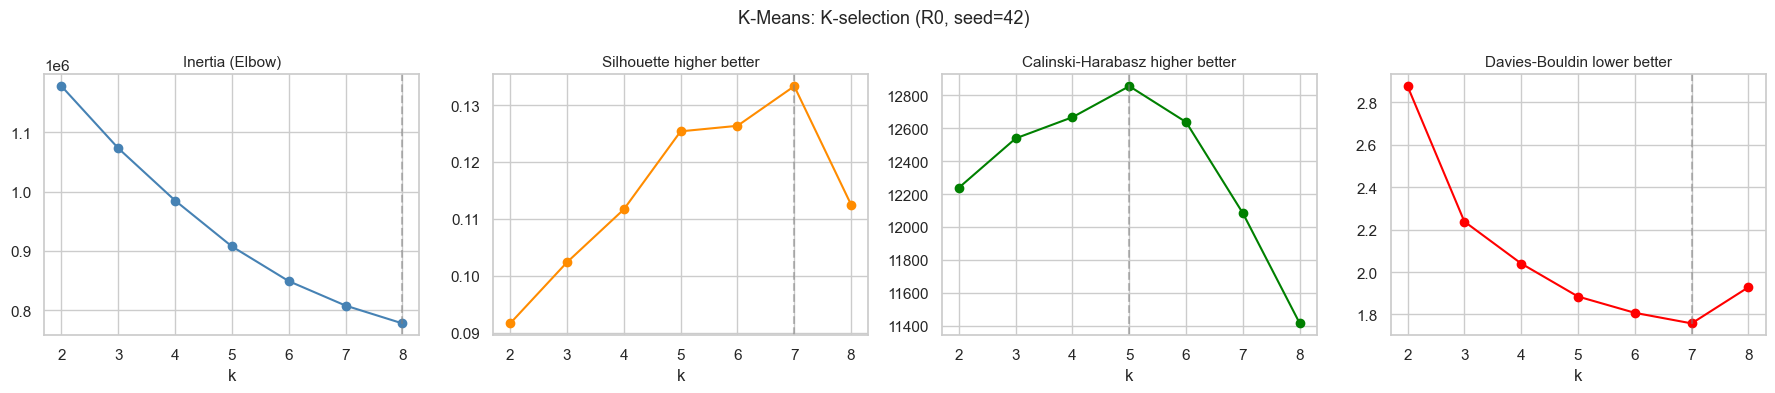

In [ ]:
#plot the metrics of k means
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metrics = [('inertia','Inertia (Elbow)','steelblue','lower'),
           ('silhouette','Silhouette higher better','darkorange','higher'),
           ('calinski_harabasz','Calinski-Harabasz higher better','green','higher'),
           ('davies_bouldin','Davies-Bouldin lower better','red','lower')]
for ax, (col, title, color, direction) in zip(axes, metrics):
    ax.plot(df_km.k, df_km[col], 'o-', color=color)
    ax.set_title(title, fontsize=11); ax.set_xlabel('k')
    best = df_km.k[df_km[col].idxmax() if direction=='higher' else df_km[col].idxmin()]
    ax.axvline(best, ls='--', color='grey', alpha=0.5)
plt.suptitle('K-Means: K-selection (R0, seed=42)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/kmeans_k_selection.png', dpi=120, bbox_inches='tight') #save figure
plt.show()

Selection charts for k: elbow (inertia), silhouette, CH, and DB.
The dashed line marks the optimal k according to each metric.
Final choice: k=7 by Silhouette (main) confirmed by decreasing DB and reasonable CH.

In [ ]:
#cluster sizes for K-Means with the best k
BEST_K = int(df_km.loc[df_km.silhouette.idxmax(), 'k']) #best k is the one with highest silhouette
print(f'Selected k={BEST_K}')

km_final=KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=GLOBAL_SEED) #algorithm with the best k
labels_km=km_final.fit_predict(X_R0) #fit

sizes=pd.Series(labels_km).value_counts().sort_index() #count how many in each cluster
print(f'Cluster sizes: {sizes.to_dict()}') #cluster sizes
print(f'Size balance: min={sizes.min()}, max={sizes.max()}, ratio={sizes.max()/sizes.min():.2f}') #ratio of largest to smallest cluster

Selected k=7
Cluster sizes: {0: 12953, 1: 20096, 2: 2021, 3: 5847, 4: 39997, 5: 10052, 6: 28244}
Size balance: min=2021, max=39997, ratio=19.79


##iK-Means — Anomalous Cluster Extraction

iK-Means automatically determines k by iteratively extracting the most anomalous cluster (the one furthest from the global mean) using a two-center iteration:

1. Calculate the global mean mu and scales by range for each feature.
2. Find the point furthest from mu (seed of the anomalous cluster).
3. Iterate: each point goes to the anomalous cluster if delta(x, c) < delta(x, mu).
4. Repeat until convergence or until no cluster of size >= min_size is found.

Normalized distance: delta_r(x, ref) = sum_j ((x_j - ref_j) / scale_j)^2

The scales are the ranges of each feature (max - min), with zeros replaced by 1.

In [ ]:
#ik means algorithm

from dataclasses import dataclass
from numpy.typing import NDArray

FloatArray = NDArray[np.float64]


@dataclass(frozen=True)
class APCluster:
   #stores cluster structure before and after
    indices:list#indices of rows that belong to this cluster
    centroid_raw: FloatArray #original centroid
    centroid_std: FloatArray#centroid in normalized space
    size:int #number of points in cluster
    scatter_pct:float#% of total scatter removed by the cluster

#compute statistics
def compute_feature_statistics(
    X: FloatArray,
    use_unit_ranges: bool = False
) -> tuple[FloatArray, FloatArray, float]:

    X = np.asarray(X, dtype=np.float64) #Format in numpy float64
    mean = X.mean(axis=0) #mean
    if use_unit_ranges:
        scales = np.ones(X.shape[1], dtype=np.float64) #unit scale
    else:
        ranges=X.max(axis=0)-X.min(axis=0) #range of each feature
        #ensure each feature contributes proportionally
        scales=np.where(ranges == 0, 1.0, ranges).astype(np.float64) #replace zero ranges with 1 to avoid division by zero
    #total scatter based on normalized distance
    diff=(X-mean)/scales # (n, d)
    D = float(np.sum(diff ** 2))
    return mean, scales, D


def normalized_squared_distances(
    X:FloatArray,
    indices:list,
    scales:FloatArray,
    reference:FloatArray
) -> FloatArray:
    Xs= np.asarray(X, dtype=np.float64)[indices] #subset of data
    diff=(Xs-reference)/scales #normalization
    return np.sum(diff ** 2, axis=1)#sum of squared differences per row


def cluster_centroid(X: FloatArray, indices: list) -> FloatArray:
    return np.asarray(X, dtype=np.float64)[indices].mean(axis=0) #compute
    #of cluster centroid


def separate_cluster(
    X:       FloatArray,
    indices: list,
    scales:  FloatArray,
    a:       FloatArray,
    b:       FloatArray
) -> list:
    X = np.asarray(X, dtype=np.float64)
    da=normalized_squared_distances(X, indices, scales, a) #distance to candidate centroid (a)
    db=normalized_squared_distances(X, indices, scales, b) #distance to reference centroid (b)
    #a point belongs to the cluster if it is closer to a than to b
    return [idx for idx, d_a, d_b in zip(indices, da, db) if d_a < d_b]


def extract_anomalous_cluster(
    X:                FloatArray,
    indices:          list,
    scales:           FloatArray,
    mean:             FloatArray,
    initial_centroid: FloatArray,
    seed_index:       int,
    tol:              float = 1e-12,
    max_iter:         int   = 10_000
) -> tuple[list, FloatArray]:
    X=np.asarray(X, dtype=np.float64)
    mean = np.asarray(mean, dtype=np.float64)
    c= np.asarray(initial_centroid, dtype=np.float64).copy() #initial centroid

    S=separate_cluster(X, indices, scales, c, mean) #initial cluster
    if len(S) == 0:
        return [], c #if empty, return
    #iterate until convergence
    for _ in range(max_iter):
        c_new=cluster_centroid(X, S) #update centroid
        S_new=separate_cluster(X, indices, scales, c_new, mean) #update cluster
        if len(S_new) == 0:
            break
            #convergence criterion:
        if np.max(np.abs(c_new - c)) < tol and set(S_new) == set(S):
            c=c_new
            S=S_new
            break
        c = c_new
        S = S_new

    return S, c


def ikmeans_initialize(
    X: FloatArray,
    min_cluster_size: int,
    tol:float = 1e-12,
    max_iter:int= 10_000,
    use_unit_ranges:bool  = False
) -> tuple[list, FloatArray]:

    X=np.asarray(X, dtype=np.float64)
    n, d = X.shape
    #global statistics
    mean_global, scales, D_total = compute_feature_statistics(X, use_unit_ranges)

    residual= list(range(n)) #points not yet assigned
    ap_clusters= [] #list of extracted clusters
    remaining_scatter = D_total

    iteration=0
    while True:
        if len(residual) < min_cluster_size:
            break #if fewer than min_cluster_size remain

        #mean of remaining points
        mu = cluster_centroid(X, residual)

        #choose point furthest from mean
        dists_from_mu = normalized_squared_distances(X, residual, scales, mu)
        seed_pos= int(np.argmax(dists_from_mu))
        seed_idx= residual[seed_pos]
        c_init= X[seed_idx].copy()

        #extract anomalous cluster
        S, c_final = extract_anomalous_cluster(
            X, residual, scales, mu, c_init, seed_idx, tol, max_iter)

        if len(S) < min_cluster_size:
            break

        #compute cluster scatter
        scatter_S = float(np.sum(((X[S] - c_final) / scales) ** 2))
        scatter_pct = (scatter_S / D_total * 100) if D_total > 0 else 0.0
        #store cluster
        ap = APCluster(indices = S,
            centroid_raw = c_final,
            centroid_std= c_final / scales,
            size= len(S),
            scatter_pct= scatter_pct,)
        ap_clusters.append(ap)

        #remove cluster from residual set
        S_set= set(S)
        residual= [i for i in residual if i not in S_set]

        iteration += 1
        print(f'iK-Means iter {iteration}: extracted cluster size={len(S)}, '
              f'scatter_pct={scatter_pct:.2f}%, residual={len(residual)}')
        if len(residual) < min_cluster_size:
            break
#if no clusters found
    if len(ap_clusters) == 0:
        init_centroids = mean_global.reshape(1, -1)
    else: #collect centroids to use in k-means
        init_centroids = np.array([c.centroid_raw for c in ap_clusters],
                                   dtype=np.float64)

    print(f'iK-Means: {len(ap_clusters)} anomalous clusters found → '
          f'init_centroids shape = {init_centroids.shape}')
    return ap_clusters, init_centroids


iK-Means iter 1: extracted cluster size=3531, scatter_pct=17.83%, residual=16469
iK-Means iter 2: extracted cluster size=3320, scatter_pct=11.77%, residual=13149
iK-Means iter 3: extracted cluster size=2046, scatter_pct=4.13%, residual=11103
iK-Means: 3 anomalous clusters found → init_centroids shape = (3, 73)
k = 3 anomalous clusters extracted
Runtime=0.4s
init_centroids shape=(3, 73)
{0: 23707, 1: 48354, 2: 47149}

Sil=0.1021  CH=12214  DB=2.4360  t=0.4s
Anomalous cluster summary:
  AP-0: size= 3531  scatter_pct=17.83%
  AP-1: size= 3320  scatter_pct=11.77%
  AP-2: size= 2046  scatter_pct=4.13%


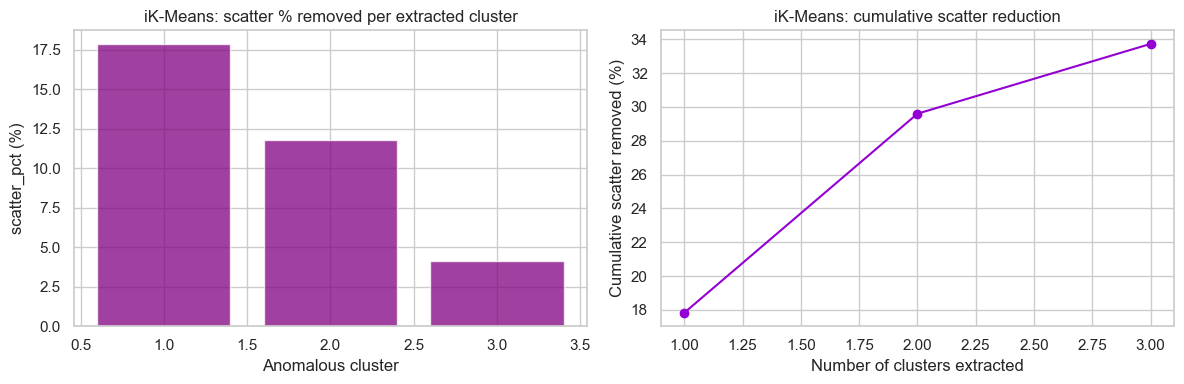

In [ ]:

SUBSAMPLE_IKM = 20000#random subsample of 20,000
np.random.seed(GLOBAL_SEED) #set seed
ikm_idx=np.random.choice(len(X_R0), size=SUBSAMPLE_IKM, replace=False) #select random indices
#of defined size
X_ikm=X_R0[ikm_idx].astype(np.float64) #create subsample

MIN_CLUSTER_SIZE = 10 #minimum cluster size to avoid tiny clusters
t0 = time.time() #start timer
#iK-Means algorithm
ap_clusters,init_centroids=ikmeans_initialize(X_ikm,min_cluster_size=MIN_CLUSTER_SIZE,
    tol=1e-12,
    max_iter=10_000,
    use_unit_ranges=False)
ikm_rt=time.time()-t0 #measure runtime

k_ikm=len(ap_clusters) #number of clusters found
print(f'k = {k_ikm} anomalous clusters extracted')
print(f'Runtime={ikm_rt:.1f}s')
print(f'init_centroids shape={init_centroids.shape}')

#run k-means with iK-Means centroids
if k_ikm >= 2: #if at least two clusters
    km_ikm = KMeans(
        n_clusters=k_ikm,
        init=init_centroids,#iK-Means centroids
        n_init=1, #single run
        max_iter=300,
        random_state=GLOBAL_SEED)
    labels_ikm_sub=km_ikm.fit_predict(X_ikm)
    ikm_centroids=km_ikm.cluster_centers_
else:
    #only 1 or 0 clusters found
    #use k-means++
    km_ikm = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=GLOBAL_SEED)
    labels_ikm_sub=km_ikm.fit_predict(X_ikm)
    ikm_centroids=km_ikm.cluster_centers_
    k_ikm=2 #set k to 2

#assign each point in X_R0 to nearest iK-Means centroid
labels_ikm=pairwise_distances_argmin(X_R0, ikm_centroids)
sizes_ikm  = pd.Series(labels_ikm).value_counts().sort_index() #count number of points per cluster
print(sizes_ikm.to_dict()) #print those sizes

#metrics
sil_ikm=silhouette_score(X_R0, labels_ikm, sample_size=5000, random_state=GLOBAL_SEED)
ch_ikm=calinski_harabasz_score(X_R0, labels_ikm)
db_ikm=davies_bouldin_score(X_R0, labels_ikm)
#print metrics
print(f'\nSil={sil_ikm:.4f}  CH={ch_ikm:.0f}  DB={db_ikm:.4f}  t={ikm_rt:.1f}s')

#percentage of scatter per cluster
print('Anomalous cluster summary:')
for i, cl in enumerate(ap_clusters): #for each iK-Means cluster
    print(f'  AP-{i}: size={cl.size:5d}  scatter_pct={cl.scatter_pct:.2f}%') #size and variance

pcts = [cl.scatter_pct for cl in ap_clusters] #list of scatter percentages
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) #create figure with 2 side-by-side plots

#axes
axes[0].bar(range(1, len(pcts)+1), pcts, color='purple', alpha=0.75)
axes[0].set_xlabel('Anomalous cluster')
axes[0].set_ylabel('scatter_pct (%)')
axes[0].set_title('iK-Means: scatter % removed per extracted cluster')

axes[1].plot(range(1, len(pcts)+1), np.cumsum(pcts), 'o-', color='darkviolet')
axes[1].set_xlabel('Number of clusters extracted')
axes[1].set_ylabel('Cumulative scatter removed (%)')
axes[1].set_title('iK-Means: cumulative scatter reduction')

plt.tight_layout()
plt.savefig('figures/ikmeans_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

## Evaluation and Robustness

In [ ]:
#compare K-Means with iK-Means
compare_rows = [] #list to collect results
for method, lbl, k in [ #for each method
    ('K-Means', labels_km, BEST_K),
    ('iK-Means', labels_ikm,k_ikm),]:
    #metrics to compare
    sil=silhouette_score(X_R0, lbl, sample_size=5000, random_state=GLOBAL_SEED)
    ch=calinski_harabasz_score(X_R0, lbl)
    db=davies_bouldin_score(X_R0, lbl)
    compare_rows.append({'method':method,'k':k,'silhouette':sil,
                          'calinski_harabasz':ch,'davies_bouldin':db})

df_compare=pd.DataFrame(compare_rows)
display(df_compare.round(4))
df_compare.to_csv('tables/method_comparison.csv', index=False) #save to csv

,method,k,silhouette,calinski_harabasz,davies_bouldin
0,K-Means,7,0.1333,12082.8667,1.7578
1,iK-Means,3,0.1021,12214.2121,2.4360


In [ ]:
SEEDS= [42, 7, 13, 99, 2025,40, 60,74,2004,2029] #10 seeds to evaluate stability

#results for the chosen option K-Means with k=7
print(f'K-Means stability: 10 seeds, k={BEST_K}')
km_stab_rows, km_stab_labels=[],[] #empty lists to store results

for seed in SEEDS: #for each seed
    km_s=KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=seed) #run k-means
    lbl=km_s.fit_predict(X_R0) #fit
    #compute metrics
    sil=silhouette_score(X_R0, lbl, sample_size=5000, random_state=seed)
    ch=calinski_harabasz_score(X_R0, lbl)
    db=davies_bouldin_score(X_R0, lbl)
    #store results for each seed
    km_stab_rows.append({'seed':seed,'silhouette':sil,'calinski_harabasz':ch,'davies_bouldin':db})
    km_stab_labels.append(lbl)

#create df
df_km_stab=pd.DataFrame(km_stab_rows)
display(df_km_stab.round(4)) #with 4 decimal places
#show mean and std with 4 decimal places
print(df_km_stab[['silhouette','calinski_harabasz','davies_bouldin']].agg(['mean','std']).round(4))
#compute ARI between seeds to assess stability
ari_km = [adjusted_rand_score(km_stab_labels[i], km_stab_labels[i+1])
          for i in range(len(SEEDS)-1)]
print(f'ARI consecutive seeds: {[round(a,4) for a in ari_km]}') #ARI for each seed pair
print(f'Mean ARI = {np.mean(ari_km):.4f}') #mean ARI

K-Means stability: 10 seeds, k=7


,seed,silhouette,calinski_harabasz,davies_bouldin
0,42,0.1333,12082.8667,1.7578
1,7,0.1404,12082.8669,1.7578
2,13,0.1385,12082.8728,1.7581
3,99,0.1362,12082.8598,1.7582
4,2025,0.1346,12082.8598,1.7582
5,40,0.1344,12082.8675,1.7578
6,60,0.1365,12082.8720,1.7581
7,74,0.1198,11868.3046,1.9514
8,2004,0.1159,11868.2998,1.9514
9,2029,0.1381,12082.8696,1.7579


      silhouette  calinski_harabasz  davies_bouldin
mean      0.1328         12039.9539          1.7967
std       0.0082            90.4684          0.0815
ARI consecutive seeds: [0.9995, 0.9981, 0.9982, 1.0, 0.9967, 0.9982, 0.5597, 0.997, 0.5589]
Mean ARI = 0.9007


In [ ]:
#iK-Means stability analysis
#do with the same seeds of k means
ikm_stab_rows = []   #metrics per run
ikm_labels_all = []  #final labels per run

for seed in SEEDS:  #vary the seed and run iK-Means for each
    np.random.seed(seed)
    #new subsample
    ikm_idx = np.random.choice(len(X_R0), size=SUBSAMPLE_IKM, replace=False)
    X_ikm = X_R0[ikm_idx].astype(np.float64)

    t0 = time.time() #measure runtime

    #iK-means
    ap_clusters, init_centroids = ikmeans_initialize(
        X_ikm,
        min_cluster_size=MIN_CLUSTER_SIZE,
        tol=1e-12,
        max_iter=10_000,
        use_unit_ranges=False )

    k_ikm = len(ap_clusters)
    #if more than 2 clusters, run k-means with iK-Means
    if k_ikm >= 2:
        km_ikm = KMeans(
            n_clusters=k_ikm,
            init=init_centroids,
            n_init=1,
            max_iter=300,
            random_state=seed)
        km_ikm.fit(X_ikm)
        ikm_centroids = km_ikm.cluster_centers_

    else:
        #fall back to k-means++
        km_ikm = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=seed)
        km_ikm.fit(X_ikm)
        ikm_centroids = km_ikm.cluster_centers_
        k_ikm = 2

    #assign to nearest cluster
    labels_ikm = pairwise_distances_argmin(X_R0, ikm_centroids)

    # metrics
    sil = silhouette_score(X_R0, labels_ikm, sample_size=5000, random_state=seed)
    ch  = calinski_harabasz_score(X_R0, labels_ikm)
    db  = davies_bouldin_score(X_R0, labels_ikm)

    ikm_stab_rows.append({
        'seed': seed,
        'k': k_ikm,   # important: k may vary!
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db})

    ikm_labels_all.append(labels_ikm)

#df results
df_ikm_stab = pd.DataFrame(ikm_stab_rows)
display(df_ikm_stab.round(4))

#mean and standard deviation
print(df_ikm_stab[['silhouette','calinski_harabasz','davies_bouldin']].agg(['mean','std']).round(4))

#ARI between consecutive runs
ari_ikm = [
    adjusted_rand_score(ikm_labels_all[i], ikm_labels_all[i+1])
    for i in range(len(SEEDS)-1)]

print(f'ARI consecutive runs: {[round(a,4) for a in ari_ikm]}')
print(f'Mean ARI = {np.mean(ari_ikm):.4f}')

iK-Means iter 1: extracted cluster size=3531, scatter_pct=17.83%, residual=16469
iK-Means iter 2: extracted cluster size=3320, scatter_pct=11.77%, residual=13149
iK-Means iter 3: extracted cluster size=2046, scatter_pct=4.13%, residual=11103
iK-Means: 3 anomalous clusters found → init_centroids shape = (3, 73)
iK-Means iter 1: extracted cluster size=3546, scatter_pct=17.95%, residual=16454
iK-Means iter 2: extracted cluster size=3314, scatter_pct=11.67%, residual=13140
iK-Means iter 3: extracted cluster size=2004, scatter_pct=4.02%, residual=11136
iK-Means: 3 anomalous clusters found → init_centroids shape = (3, 73)
iK-Means iter 1: extracted cluster size=3540, scatter_pct=17.80%, residual=16460
iK-Means iter 2: extracted cluster size=3354, scatter_pct=11.99%, residual=13106
iK-Means iter 3: extracted cluster size=2003, scatter_pct=4.06%, residual=11103
iK-Means iter 4: extracted cluster size=1589, scatter_pct=6.31%, residual=9514
iK-Means: 4 anomalous clusters found → init_centroids s

,seed,k,silhouette,calinski_harabasz,davies_bouldin
0,42,3,0.1021,12214.2121,2.4360
1,7,3,0.1095,12211.9230,2.4399
2,13,4,0.0961,10714.4698,2.4650
3,99,7,0.1119,11001.4977,1.9660
4,2025,8,0.0989,9894.3665,2.1873
5,40,6,0.0943,9462.0855,2.2445
6,60,3,0.1073,12200.4256,2.4460
7,74,6,0.0864,9283.0114,2.3384
8,2004,3,0.1021,12212.7882,2.4334
9,2029,6,0.0963,9455.4812,2.2366


      silhouette  calinski_harabasz  davies_bouldin
mean      0.1005         10865.0261          2.3193
std       0.0077          1276.9534          0.1611
ARI consecutive runs: [0.9633, 0.5459, 0.6194, 0.8684, 0.4315, 0.2588, 0.3141, 0.3137, 0.2933]
Mean ARI = 0.5120


In [ ]:
#r0 vs r1

sens_rows, lbl_dict=[],{} #list for metrics and dict for labels
for rep_id, X_rep, scaler_name in [('R0-standard-noADR', X_R0, 'StandardScaler'), #with R0
    ('R1-robust-noADR',   X_R1, 'RobustScaler'),]: #with R1
    km_s=KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=GLOBAL_SEED) #K-Means algorithm with k-means++
    lbl=km_s.fit_predict(X_rep) #fit
    #metrics for each representation
    sil=silhouette_score(X_rep, lbl, sample_size=5000, random_state=GLOBAL_SEED)
    ch=calinski_harabasz_score(X_rep, lbl)
    db=davies_bouldin_score(X_rep, lbl)
    #append from ri, the type of scaling and the metrics
    sens_rows.append({'representation_id':rep_id,'scaler':scaler_name,
                      'silhouette':sil,'calinski_harabasz':ch,'davies_bouldin':db})
    #store labels
    lbl_dict[rep_id] = lbl
#create df
df_sens = pd.DataFrame(sens_rows)
display(df_sens.round(4)) #show with 4 decimal places
ari_scale = adjusted_rand_score(lbl_dict['R0-standard-noADR'], lbl_dict['R1-robust-noADR']) #compute ari
print(f'ARI(R0 vs R1)={ari_scale:.4f}')
df_sens.to_csv('tables/sensitivity_scaler.csv', index=False) #save the table

,representation_id,scaler,silhouette,calinski_harabasz,davies_bouldin
0,R0-standard-noADR,StandardScaler,0.1333,12082.8667,1.7578
1,R1-robust-noADR,RobustScaler,0.1103,10577.1397,2.1589


ARI(R0 vs R1)=0.2835


In [ ]:

# Sensitivity: with hotel vs without hotel variable
# Tests whether clusters are trivially driven by property type

CATEG_NO_HOTEL= [c for c in CATEGORICAL_FEATURES if c != 'hotel']
ALL_NO_HOTEL= NUMERICAL_FEATURES + BINARY_FEATURES + CATEG_NO_HOTEL

prep_nh = ColumnTransformer([
    ('num', Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())]), NUMERICAL_FEATURES),
    ('bin', 'passthrough', BINARY_FEATURES),
    ('cat', Pipeline([('imp',SimpleImputer(strategy='most_frequent')),
                      ('ohe',OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CATEG_NO_HOTEL),
])
X_nohotel = prep_nh.fit_transform(df2[ALL_NO_HOTEL])

#method
#metrics
km_nh   = KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=GLOBAL_SEED)
lbl_nh  = km_nh.fit_predict(X_nohotel)
sil_nh  = silhouette_score(X_nohotel, lbl_nh, sample_size=5000, random_state=GLOBAL_SEED)
ari_hotel = adjusted_rand_score(labels_km, lbl_nh)

print(f'With hotel   : Sil={silhouette_score(X_R0, labels_km, sample_size=5000, random_state=GLOBAL_SEED):.4f}')
print(f'Without hotel: Sil={sil_nh:.4f}')
print(f'ARI(with vs without hotel) = {ari_hotel:.4f}')
print()

With hotel   : Sil=0.1333
Without hotel: Sil=0.1374
ARI(with vs without hotel) = 0.9113



##Cluster Profiling

In [ ]:
#show cluster sizes

df_prof=df2.copy() #copy the df
df_prof['cluster_km']=labels_km #from k-means

#for k means
CL='cluster_km'

print(f'Cluster sizes ({CL}):')
display(df_prof[CL].value_counts().sort_index().rename('n')) #count cluster sizes

Cluster sizes (cluster_km):


cluster_km
0    12953
1    20096
2     2021
3     5847
4    39997
5    10052
6    28244
Name: n, dtype: int64

In [ ]:
#numerical profile for each cluster
num_prof_cols = ['lead_time','total_nights','party_size',
                 'previous_cancellations','previous_bookings_not_canceled',
                 'total_of_special_requests','required_car_parking_spaces'] #numerical features
prof_num = df_prof.groupby(CL)[num_prof_cols].agg(['mean','median']).round(2) #compute mean and median for each feature above
display(prof_num) #display the table
prof_num.to_csv('tables/profile_numerical.csv') #save the table

lead_time        total_nights        party_size         \
                mean median         mean median       mean median   
cluster_km                                                          
0             139.47  128.0         8.45    7.0       1.98    2.0   
1               5.71    3.0         1.87    1.0       1.61    2.0   
2              14.58    3.0         1.71    1.0       1.21    1.0   
3             213.64  257.0         2.73    2.0       1.84    2.0   
4             147.95  113.0         2.83    3.0       1.80    2.0   
5              88.25   66.0         3.59    3.0       3.45    3.0   
6              85.20   61.0         3.28    3.0       2.01    2.0   

           previous_cancellations        previous_bookings_not_canceled  \
                             mean median                           mean   
cluster_km                                                                
0                            0.00    0.0                           0.01   
1                            0.00    0.0                           0.05   
2                            0.59    0.0                           7.26   
3                            1.56    1.0                           0.02   
4                            0.00    0.0                           0.00   
5                            0.00    0.0                           0.00   
6                            0.00    0.0                           0.01   

                  total_of_special_requests         \
           median                      mean median   
cluster_km                                           
0             0.0                      0.51    0.0   
1             0.0                      0.31    0.0   
2             4.0                      0.74    0.0   
3             0.0                      0.12    0.0   
4             0.0                      0.08    0.0   
5             0.0                      0.59    0.0   
6             0.0                      1.55    1.0   

           required_car_parking_spaces         
                                  mean median  
cluster_km                                     
0                                 0.07    0.0  
1                                 0.13    0.0  
2                                 0.22    0.0  
3                                 0.00    0.0  
4                                 0.02    0.0  
5                                 0.10    0.0  
6                                 0.07    0.0

In [ ]:
#categorical profile of clusters
#categorical features
cat_prof_cols = ['hotel','market_segment','distribution_channel',
                 'deposit_type','customer_type','meal_clean','reserved_room_type','country_grouped']
for col in cat_prof_cols:
    ct = pd.crosstab(df_prof[CL], df_prof[col], normalize='index') * 100 #percentage of category
    #within cluster
    print(f'\n {col} (% within cluster)')
    display(ct.round(1))


 hotel (% within cluster)


hotel,City Hotel,Resort Hotel
cluster_km,,
0,16.9,83.1
1,51.9,48.1
2,49.7,50.3
3,85.1,14.9
4,83.3,16.7
5,67.0,33.0
6,72.6,27.4



 market_segment (% within cluster)


market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
cluster_km,,,,,,,,
0,0.2,0.1,1.6,11.9,9.2,35.5,41.6,0.0
1,0.9,2.1,13.7,30.4,5.4,11.1,36.5,0.0
2,1.0,7.8,61.5,15.6,1.2,3.6,9.3,0.0
3,0.1,0.2,3.0,2.1,56.8,28.3,9.5,0.0
4,0.0,0.1,2.1,3.7,34.9,34.6,24.7,0.0
5,0.0,0.3,0.5,15.1,0.8,7.7,75.5,0.0
6,0.0,0.2,0.1,5.3,0.4,3.6,90.2,0.0



 distribution_channel (% within cluster)


...

meal_clean,BB,FB,HB,SC
cluster_km,,,,
0,65.0,1.4,28.7,4.9
1,84.1,0.2,5.1,10.5
2,96.4,0.1,2.2,1.3
3,82.1,1.7,14.6,1.7
4,76.0,1.0,14.1,8.8
5,86.0,0.5,11.8,1.7
6,74.8,0.0,7.0,18.2



 reserved_room_type (% within cluster)


reserved_room_type,A,B,C,D,E,F,G,H,L
cluster_km,,,,,,,,,
0,49.6,0.5,0.9,29.4,15.1,2.9,1.3,0.3,0.0
1,76.4,0.7,0.4,12.9,6.0,2.2,1.1,0.2,0.0
2,84.0,0.5,0.2,7.3,5.1,1.4,1.3,0.0,0.0
3,95.3,0.8,0.1,2.6,0.9,0.2,0.1,0.0,0.0
4,88.4,0.8,0.1,8.2,2.1,0.3,0.1,0.0,0.0
5,22.7,1.0,6.3,28.3,6.3,15.7,14.7,5.0,0.0
6,67.9,1.5,0.2,22.4,6.2,1.1,0.5,0.1,0.0



 country_grouped (% within cluster)


country_grouped,AUT,BEL,BRA,CHE,CN,DEU,ESP,FRA,GBR,IRL,ITA,NLD,Other,PRT,SWE,USA
cluster_km,,,,,,,,,,,,,,,,
0,0.9,1.5,1.2,1.3,1.2,5.4,4.5,5.5,28.0,8.7,1.4,1.8,8.8,28.1,1.0,0.7
1,0.7,1.3,1.4,0.9,0.7,3.1,9.8,6.2,5.7,1.2,2.5,1.7,9.8,52.2,0.6,2.2
2,0.2,0.2,0.1,0.0,0.0,0.1,1.1,1.7,1.4,0.1,0.2,0.3,7.5,86.9,0.0,0.0
3,0.0,0.3,0.1,0.0,0.0,0.1,0.6,0.1,1.7,1.1,0.0,0.0,0.4,95.5,0.1,0.0
4,1.2,1.4,1.3,1.1,1.1,8.3,5.0,8.9,6.7,1.5,3.3,1.1,7.5,49.4,0.8,1.3
5,1.2,2.8,3.5,2.2,1.1,4.9,12.1,10.8,10.1,2.6,5.2,2.2,13.9,23.4,1.3,2.8
6,1.4,3.6,3.3,2.5,1.5,7.6,9.6,13.3,12.5,3.9,4.3,3.0,12.4,17.4,1.1,2.8


In [ ]:
#Post-hoc profiling (leakage variables NOT used to form clusters)
posthoc_num = ['is_canceled','adr','booking_changes'] #features not used for clustering
display(df_prof.groupby(CL)[posthoc_num].agg(['mean','median']).round(3))
print()
print('Cancellation rate per cluster:')
display(df_prof.groupby(CL)['is_canceled'].mean().rename('cancel_rate').round(3))
print()
print('Reservation status distribution (%):')
display((pd.crosstab(df_prof[CL], df_prof['reservation_status'], normalize='index')*100).round(1))
df_prof.groupby(CL)[posthoc_num].agg(['mean','median']).to_csv('tables/profile_posthoc.csv')

is_canceled             adr         booking_changes       
                  mean median     mean  median            mean median
cluster_km                                                           
0                0.328    0.0  101.384   88.00           0.317    0.0
1                0.131    0.0   86.876   80.25           0.221    0.0
2                0.056    0.0   61.455   65.00           0.279    0.0
3                0.990    1.0   77.530   69.00           0.028    0.0
4                0.512    1.0   93.183   90.00           0.181    0.0
5                0.411    0.0  162.259  157.50           0.323    0.0
6                0.241    0.0  111.920  107.10           0.223    0.0


Cancellation rate per cluster:


cluster_km
0    0.328
1    0.131
2    0.056
3    0.990
4    0.512
5    0.411
6    0.241
Name: cancel_rate, dtype: float64


Reservation status distribution (%):


reservation_status,Canceled,Check-Out,No-Show
cluster_km,,,
0,31.6,67.2,1.2
1,11.3,86.9,1.8
2,4.7,94.4,0.9
3,98.9,1.0,0.1
4,50.3,48.8,0.9
5,40.2,58.9,0.9
6,23.3,75.9,0.8


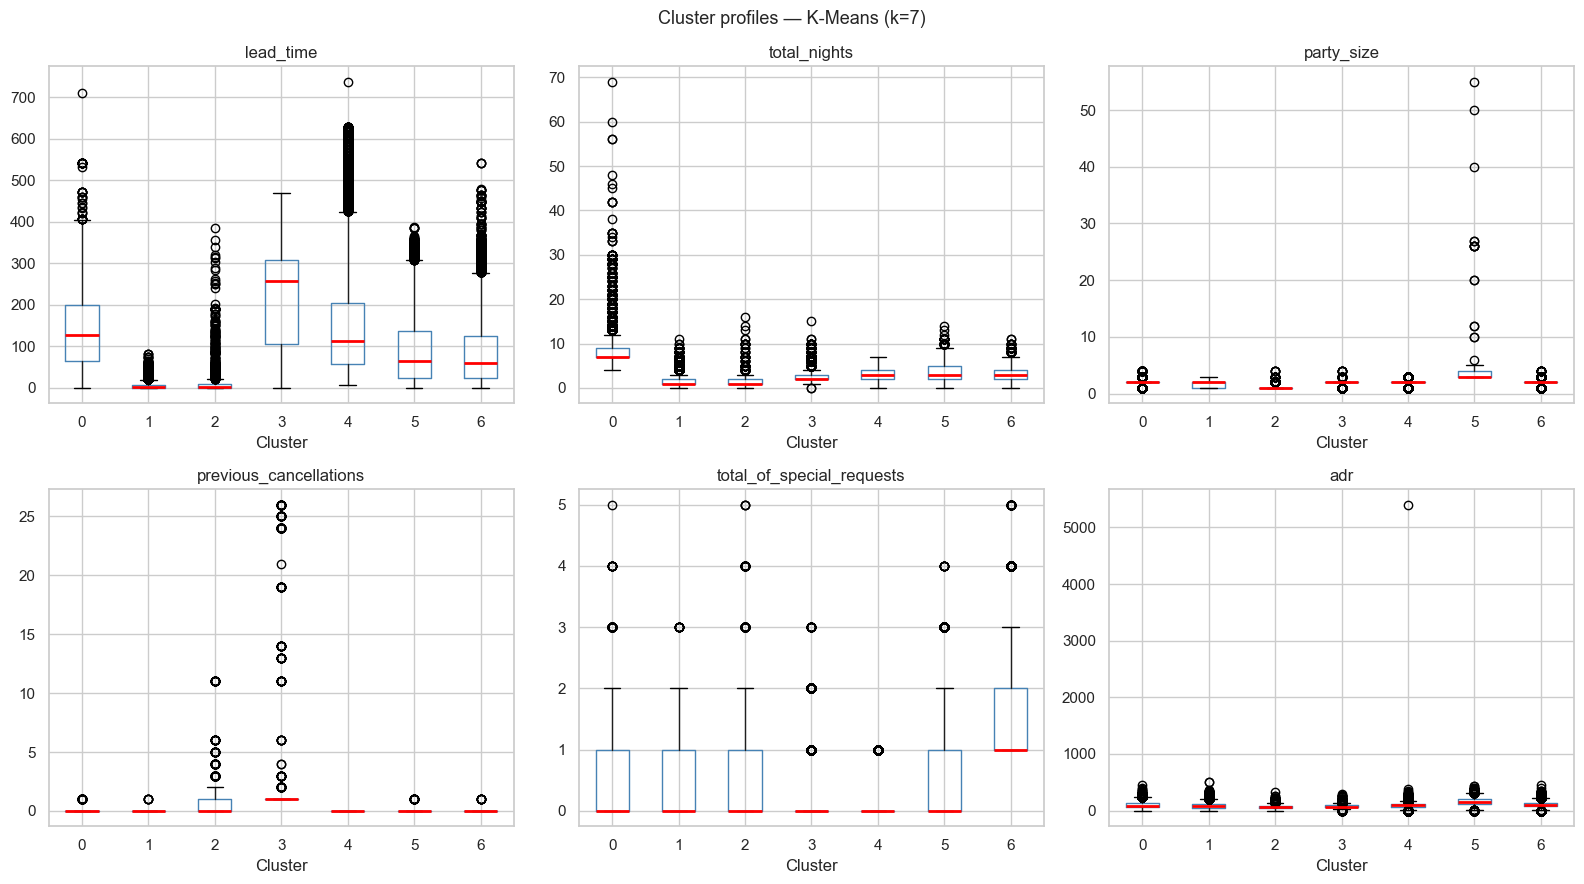

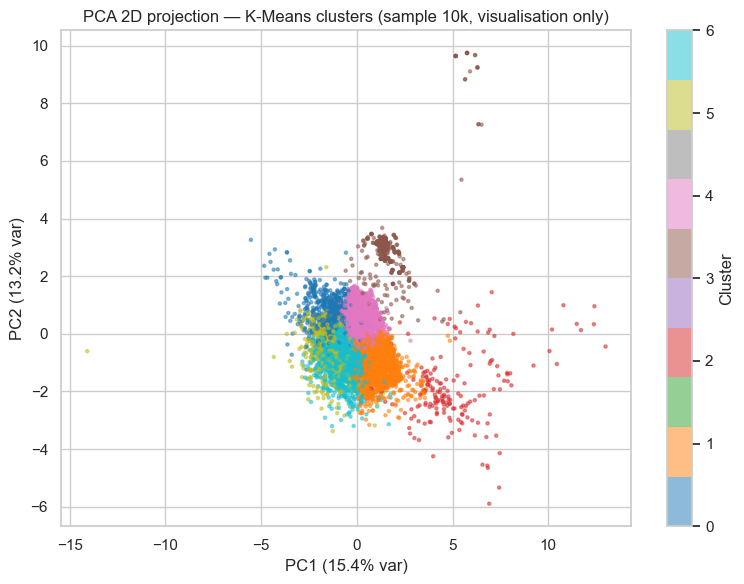

In [ ]:
#visual profiles of clusters (plots)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, ['lead_time','total_nights','party_size',
                                'previous_cancellations','total_of_special_requests','adr']):
    df_prof.boxplot(column=col, by=CL, ax=ax, notch=False,
                    boxprops=dict(color='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title(col); ax.set_xlabel('Cluster')
plt.suptitle(f'Cluster profiles — K-Means (k={BEST_K})', fontsize=13)
plt.tight_layout()
plt.savefig('figures/profiles_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

#PCA 2D visualisation
pca2 = PCA(n_components=2, random_state=GLOBAL_SEED) #2 components
viz_idx = np.random.choice(len(X_R0), 10000, replace=False)
X2d  = pca2.fit_transform(X_R0[viz_idx])
lbl2d = labels_km[viz_idx]
plt.figure(figsize=(8,6))
sc = plt.scatter(X2d[:,0], X2d[:,1], c=lbl2d, cmap='tab10', s=5, alpha=0.5)
plt.colorbar(sc, label='Cluster')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA 2D projection — K-Means clusters (sample 10k, visualisation only)')
plt.tight_layout()
plt.savefig('figures/pca2d_clusters.png', dpi=120, bbox_inches='tight')
plt.show()

##Experiments Log

In [ ]:
import datetime
exp_rows=[] #to store

RUN_TS=datetime.datetime.now().strftime('%Y-%m-%dT%H:%M:%S')  #timestamp unique for each time we run

#K-Means k-sweep
for i, r in enumerate(results_km):
    exp_rows.append({
        'run_id': f'km-sweep-k{r["k"]}',
        'date': RUN_TS,
        'method': 'KMeans',
        'representation_id': 'R0-standard-noADR',
        'parameters': f'k={r["k"]}, init=k-means++, n_init=10',
        'sample_rule': 'full dataset',
        'k': r['k'],
        'seed' : GLOBAL_SEED,
        'silhouette': round(r['silhouette'],4),
        'calinski_harabasz': round(r['calinski_harabasz'],2),
        'davies_bouldin': round(r['davies_bouldin'],4),
        'inertia': round(r['inertia'],1),
        'runtime_s': round(r['runtime_s'],2),
        'diagnostics': 'converged',
        'notes' : 'KMeans k-sweep',})

#iK-Means
exp_rows.append({
    'run_id': 'ikmeans-auto',
    'date': RUN_TS,
    'method': 'iKMeans',
    'representation_id': 'R0-standard-noADR',
    'parameters': f'min_cluster_size=10, tol=1e-12, max_iter=10000',
    'sample_rule': f'subsample={SUBSAMPLE_IKM}, seed={GLOBAL_SEED}',
    'k': k_ikm,
    'seed': GLOBAL_SEED,
    'silhouette': round(sil_ikm,4),
    'calinski_harabasz': round(ch_ikm,2),
    'davies_bouldin': round(db_ikm,4),
    'inertia': None,
    'runtime_s': round(ikm_rt,2),
    'diagnostics' : f'{k_ikm} anomalous clusters extracted',
    'notes': f'auto-k; full assign via pairwise_distances_argmin',})

#KMeans stability seeds
for r in km_stab_rows:
    exp_rows.append({
        'run_id': f'km-stab-seed{r["seed"]}',
        'date': RUN_TS,
        'method': 'KMeans-stability',
        'representation_id': 'R0-standard-noADR',
        'parameters': f'k={BEST_K}, init=k-means++, n_init=10',
        'sample_rule': 'full dataset',
        'k': BEST_K,
        'seed' : r['seed'],
        'silhouette': round(r['silhouette'],4),
        'calinski_harabasz': round(r['calinski_harabasz'],2),
        'davies_bouldin': round(r['davies_bouldin'],4),
        'inertia': None,
        'runtime_s': None,
        'diagnostics': 'converged',
        'notes':'seed stability',
    })

#Scaler sensitivity
for r in sens_rows:
    exp_rows.append({
        'run_id': f'km-sens-{r["representation_id"]}',
        'date': RUN_TS,
        'method': 'KMeans-sensitivity',
        'representation_id': r['representation_id'],
        'parameters': f'k={BEST_K}, scaler={r["scaler"]}',
        'sample_rule': 'full dataset',
        'k': BEST_K,
        'seed' : GLOBAL_SEED,
        'silhouette': round(r['silhouette'],4),
        'calinski_harabasz': round(r['calinski_harabasz'],2),
        'davies_bouldin' : round(r['davies_bouldin'],4),
        'inertia': None,
        'runtime_s': None,
        'diagnostics' : 'converged',
        'notes': f'scaler={r["scaler"]}',
    })

df_exp = pd.DataFrame(exp_rows)
df_exp.to_csv('experiments.csv', index=False)
print(f'Saved {len(df_exp)} rows to experiments.csv')
display(df_exp.head(8))

Saved 20 rows to experiments.csv


,run_id,date,method,representation_id,parameters,sample_rule,k,seed,silhouette,calinski_harabasz,davies_bouldin,inertia,runtime_s,diagnostics,notes
0,km-sweep-k2,2026-04-30T17:36:00,KMeans,R0-standard-noADR,"k=2, init=k-means++, n_init=10",full dataset,2,42,0.0916,12238.41,2.8761,1177895.4,0.57,converged,KMeans k-sweep
1,km-sweep-k3,2026-04-30T17:36:00,KMeans,R0-standard-noADR,"k=3, init=k-means++, n_init=10",full dataset,3,42,0.1024,12537.92,2.2379,1073092.7,0.70,converged,KMeans k-sweep
2,km-sweep-k4,2026-04-30T17:36:00,KMeans,R0-standard-noADR,"k=4, init=k-means++, n_init=10",full dataset,4,42,0.1117,12666.56,2.0401,984872.4,0.66,converged,KMeans k-sweep
3,km-sweep-k5,2026-04-30T17:36:00,KMeans,R0-standard-noADR,"k=5, init=k-means++, n_init=10",full dataset,5,42,0.1254,12854.73,1.8844,907412.3,0.71,converged,KMeans k-sweep
4,km-sweep-k6,2026-04-30T17:36:00,KMeans,R0-standard-noADR,"k=6, init=k-means++, n_init=10",full dataset,6,42,0.1264,12636.53,1.8076,848883.0,0.70,converged,KMeans k-sweep
5,km-sweep-k7,2026-04-30T17:36:00,KMeans,R0-standard-noADR,"k=7, init=k-means++, n_init=10",full dataset,7,42,0.1333,12082.87,1.7578,807634.2,0.79,converged,KMeans k-sweep
6,km-sweep-k8,2026-04-30T17:36:00,KMeans,R0-standard-noADR,"k=8, init=k-means++, n_init=10",full dataset,8,42,0.1125,11414.82,1.9284,777588.4,0.83,converged,KMeans k-sweep
7,ikmeans-auto,2026-04-30T17:36:00,iKMeans,R0-standard-noADR,"min_cluster_size=10, tol=1e-12, max_iter=10000","subsample=20000, seed=42",6,42,0.1021,12214.21,2.4360,NaN,0.38,6 anomalous clusters extracted,auto-k; full assign via pairwise_distances_argmin


## Reproducibility Artefacts

In [ ]:
#Generate environment.yml and run_all.py
env_yml = '''name: hotel-clustering
channels:
  - defaults
  - conda-forge
dependencies:
  - python=3.10
  - numpy>=1.24
  - pandas>=1.5
  - scikit-learn>=1.3
  - scipy>=1.10
  - matplotlib>=3.7
  - seaborn>=0.12
  - jupyter
  - jupyterlab
  - pip
  - pip:
    - yellowbrick
'''

run_all_py = '''#!/usr/bin/env python
"""
run_all.py — single entry-point that regenerates all results.
Usage:
    python run_all.py # full run
    python run_all.py --fast # fast-check mode (small subsample)
"""
import subprocess, sys, os

fast = '--fast' in sys.argv
cmd  = ['jupyter', 'nbconvert', '--to', 'notebook', '--execute',
        '--ExecutePreprocessor.timeout=3600',
        'hotel_clustering_complete.ipynb',
        '--output', 'hotel_clustering_complete_executed.ipynb']
if fast:
    print('[FAST MODE] Running notebook with reduced subsamples...')
subprocess.run(cmd, check=True)
print('Done — executed notebook saved to hotel_clustering_complete_executed.ipynb')
print('Figures: ./figures/   Tables: ./tables/   Log: experiments.csv')
'''

with open('environment.yml', 'w') as f: f.write(env_yml) #gera ficheiro
with open('run_all.py', 'w') as f: f.write(run_all_py) #gera ficheiro
